# CH 6 DATA-MINING BIAS AS A FUNCTION OF RULE CORRELATION IN A UNIVERSE OF VARIABLE MERIT BASED ON 500 ATRs

> **Eurêka final :** la corrélation entre règles réduit le **nombre effectif de tests**. Elle diminue donc le **biais de minage de données**, mais elle réduit aussi le **pouvoir de découverte** d’une vraie règle supérieure.

Dans ce notebook, on va simuler un univers de **500 règles artificielles de trading** avec un **mérite variable**.

L’objectif est de visualiser deux effets opposés :

| Corrélation entre règles | Biais de minage | Pouvoir de découverte |
|---:|---:|---:|
| Faible | Élevé | Élevé |
| Forte | Faible | Faible |

Autrement dit :

> Plus les règles sont différentes, plus on peut trouver une vraie pépite, mais plus le risque de se faire tromper par la chance augmente.

## 1. Intuition simple

Imagine 500 règles de trading.

Certaines ont un vrai mérite supérieur, d’autres sont médiocres.

Quand tu fais du **data mining**, tu testes plusieurs règles et tu sélectionnes celle qui affiche la meilleure performance observée.

Le piège est le suivant :

$$
\text{performance observée} = \text{mérite réel} + \text{bruit d'échantillonnage}
$$

Si les règles sont très peu corrélées, chaque règle apporte un bruit différent.

Donc le hasard a beaucoup d’occasions de créer un faux gagnant.

Si les règles sont très corrélées, elles bougent toutes presque pareil.

Donc le hasard a moins d’occasions de créer un gagnant artificiel.

Mais cette protection a un prix : si toutes les règles se ressemblent, tu explores moins d’idées réellement différentes.

## 2. Le mécanisme mathématique

La corrélation réduit le **nombre effectif de règles indépendantes**.

Une approximation intuitive du nombre effectif de tests est :

$$
N_{\text{eff}} \approx \frac{N}{1 + (N - 1)\rho}
$$

où :

| Symbole | Signification |
|---|---|
| $N$ | nombre total de règles testées |
| $\rho$ | corrélation moyenne entre règles |
| $N_{\text{eff}}$ | nombre approximatif de règles indépendantes |

Cette formule est volontairement simplifiée.

Elle ne remplace pas un test robuste comme le **White Reality Check**, mais elle donne l’intuition correcte :

$$
\rho \uparrow \quad \Rightarrow \quad N_{\text{eff}} \downarrow
$$

Donc :

$$
\text{biais de minage} \downarrow
$$

Mais aussi :

$$
\text{diversité explorée} \downarrow
$$

## 3. Simulation EBTA simplifiée

On va créer :

- **500 règles artificielles**.
- Un **mérite réel** différent pour chaque règle.
- **100 observations** par règle, comme dans l’esprit de la figure citée.
- Quatre niveaux de corrélation : $0.0$, $0.3$, $0.6$, $0.9$.
- Plusieurs tailles de recherche : tester $1$, $2$, $4$, ..., $256$ règles.

Pour chaque expérience :

1. On tire un univers de mérites réels.
2. On génère des performances observées corrélées.
3. On sélectionne la règle avec la meilleure performance observée.
4. On mesure :
   - sa **performance observée** ;
   - son **mérite réel attendu** ;
   - le **biais**, défini comme l’écart entre les deux.

$$
\text{biais} = \text{performance observée du gagnant} - \text{mérite réel du gagnant}
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproductibilité
rng = np.random.default_rng(42)

# Paramètres globaux
N_RULES = 500
N_OBS = 100
N_EXPERIMENTS = 1_000

SEARCH_SIZES = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256])
CORRELATIONS = [0.0, 0.3, 0.6, 0.9]

# Hypothèse pédagogique :
# Les mérites réels sont centrés autour de +1.4% par mois,
# avec une dispersion qui permet à certaines règles d'être meilleures.
MEAN_MERIT = 0.014
STD_MERIT = 0.012

# Volatilité mensuelle du bruit d'échantillonnage
NOISE_STD = 0.06

print("Notebook prêt.")

Notebook prêt.


## 4. Fonction de simulation

On utilise un modèle à facteur commun pour générer des règles corrélées.

Pour une règle $i$ et une observation $t$ :

$$
\varepsilon_{i,t}
=
\sqrt{\rho}F_t
+
\sqrt{1 - \rho}U_{i,t}
$$

où :

- $F_t$ est le **bruit commun** à toutes les règles.
- $U_{i,t}$ est le **bruit spécifique** de chaque règle.
- $\rho$ contrôle le niveau de corrélation.

Quand $\rho = 0$, les règles sont indépendantes.

Quand $\rho = 0.9$, elles partagent presque tout leur bruit.

In [2]:
def simulate_one_universe(rule_corr, search_size, rng):
    """
    Simule un univers de règles de trading et retourne les statistiques
    du gagnant sélectionné par data mining.
    """
    # Mérite réel de chaque règle
    true_merits = rng.normal(MEAN_MERIT, STD_MERIT, size=N_RULES)

    # On ne teste que search_size règles dans l'univers
    selected_indices = rng.choice(N_RULES, size=search_size, replace=False)
    tested_merits = true_merits[selected_indices]

    # Bruit corrélé par observation
    common_noise = rng.normal(0, NOISE_STD, size=(N_OBS, 1))
    idio_noise = rng.normal(0, NOISE_STD, size=(N_OBS, search_size))

    noise = np.sqrt(rule_corr) * common_noise + np.sqrt(1 - rule_corr) * idio_noise

    # Historique de rendement observé de chaque règle
    returns = tested_merits.reshape(1, -1) + noise

    # Performance observée = moyenne historique
    observed_perf = returns.mean(axis=0)

    # Data mining : on garde la meilleure règle observée
    winner = np.argmax(observed_perf)

    return {
        "corr": rule_corr,
        "search_size": search_size,
        "winner_observed": observed_perf[winner],
        "winner_true_merit": tested_merits[winner],
        "bias": observed_perf[winner] - tested_merits[winner],
    }


def run_simulation():
    rows = []

    for corr in CORRELATIONS:
        for search_size in SEARCH_SIZES:
            for _ in range(N_EXPERIMENTS):
                rows.append(simulate_one_universe(corr, search_size, rng))

    return pd.DataFrame(rows)

results = run_simulation()

summary = (
    results
    .groupby(["corr", "search_size"], as_index=False)
    .agg(
        observed_mean=("winner_observed", "mean"),
        true_merit_mean=("winner_true_merit", "mean"),
        bias_mean=("bias", "mean"),
    )
)

summary.head()

,corr,search_size,observed_mean,true_merit_mean,bias_mean
0,0.0,1,0.013927,0.013911,0.000015
1,0.0,2,0.021571,0.019990,0.001581
2,0.0,4,0.027580,0.024816,0.002764
3,0.0,8,0.033674,0.029683,0.003991
4,0.0,16,0.038039,0.033339,0.004700


## 5. Résultat 1 — la performance observée du gagnant

Ce premier graphique montre ce que le trader voit dans son backtest.

Quand le nombre de règles testées augmente, la meilleure performance observée monte.

Mais attention :

> Ce que tu observes n’est pas forcément ce que tu peux attendre dans le futur.

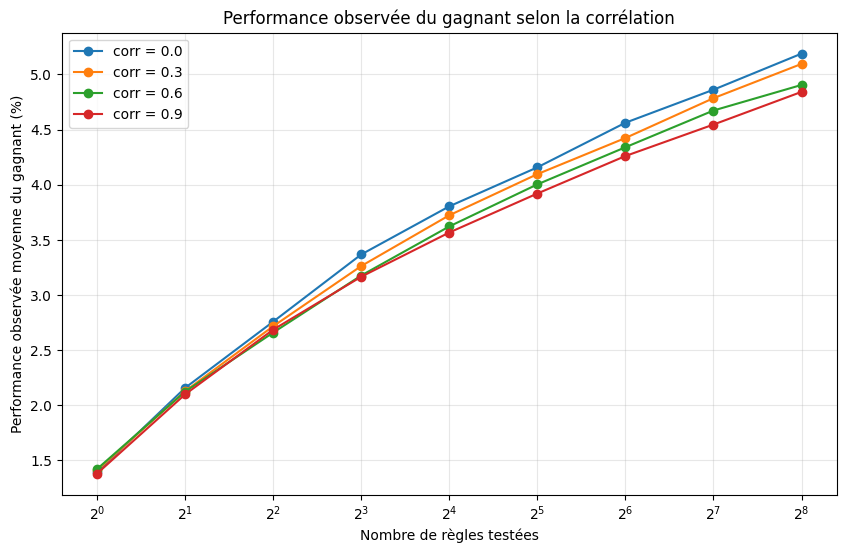

In [3]:
plt.figure(figsize=(10, 6))

for corr in CORRELATIONS:
    subset = summary[summary["corr"] == corr]
    plt.plot(
        subset["search_size"],
        subset["observed_mean"] * 100,
        marker="o",
        label=f"corr = {corr}"
    )

plt.xscale("log", base=2)
plt.xlabel("Nombre de règles testées")
plt.ylabel("Performance observée moyenne du gagnant (%)")
plt.title("Performance observée du gagnant selon la corrélation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Résultat 2 — le mérite réel du gagnant

Ce deuxième graphique est le plus important pour comprendre l’envers de la médaille.

Il mesure le **mérite réel** de la règle sélectionnée.

Quand les règles sont peu corrélées, tester plus de règles permet réellement de trouver une règle avec un meilleur mérite.

Quand les règles sont très corrélées, tester plus de variantes apporte peu d’information nouvelle.

> La corrélation protège contre le biais, mais elle peut rendre la recherche stérile.

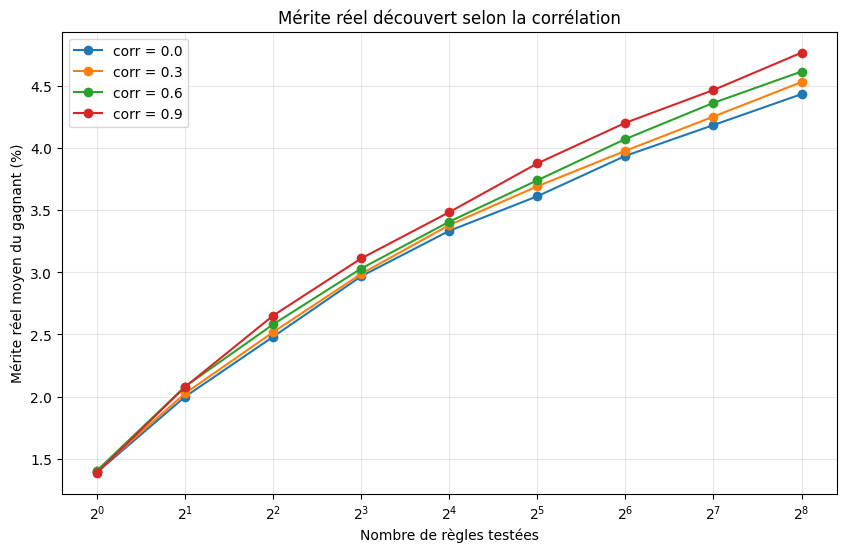

In [4]:
plt.figure(figsize=(10, 6))

for corr in CORRELATIONS:
    subset = summary[summary["corr"] == corr]
    plt.plot(
        subset["search_size"],
        subset["true_merit_mean"] * 100,
        marker="o",
        label=f"corr = {corr}"
    )

plt.xscale("log", base=2)
plt.xlabel("Nombre de règles testées")
plt.ylabel("Mérite réel moyen du gagnant (%)")
plt.title("Mérite réel découvert selon la corrélation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Résultat 3 — le biais de minage de données

Le biais correspond à l’écart entre la performance observée et le mérite réel.

$$
\text{biais}
=
\text{performance observée}
-
\text{mérite réel}
$$

Quand la corrélation est faible, les règles sont plus indépendantes.

Le hasard a donc plus d’occasions de créer un faux gagnant.

Quand la corrélation est forte, le biais baisse parce que les règles se ressemblent.

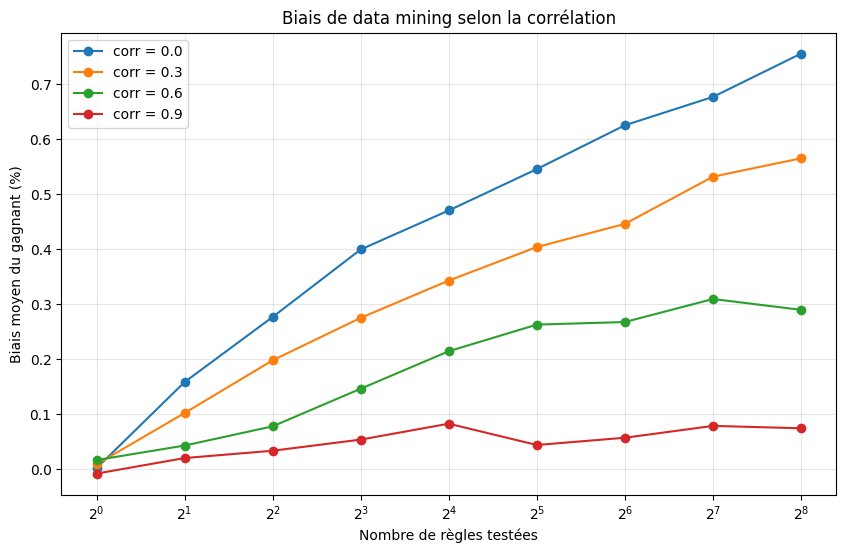

In [5]:
plt.figure(figsize=(10, 6))

for corr in CORRELATIONS:
    subset = summary[summary["corr"] == corr]
    plt.plot(
        subset["search_size"],
        subset["bias_mean"] * 100,
        marker="o",
        label=f"corr = {corr}"
    )

plt.xscale("log", base=2)
plt.xlabel("Nombre de règles testées")
plt.ylabel("Biais moyen du gagnant (%)")
plt.title("Biais de data mining selon la corrélation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Lecture des résultats en tableau

Ce tableau résume les résultats pour $256$ règles testées.

Il permet de voir le compromis :

| Corrélation | Effet principal |
|---:|---|
| $0.0$ | forte exploration, mais biais élevé |
| $0.3$ | compromis intermédiaire |
| $0.6$ | moins de biais, moins de découverte |
| $0.9$ | faible exploration réelle |

Le point clé n’est pas de chercher une corrélation nulle à tout prix.

Le point clé est de comprendre le **prix statistique** de la diversité.

In [6]:
table_256 = summary[summary["search_size"] == 256].copy()

table_256["observed_mean_%"] = table_256["observed_mean"] * 100
table_256["true_merit_mean_%"] = table_256["true_merit_mean"] * 100
table_256["bias_mean_%"] = table_256["bias_mean"] * 100

display(
    table_256[
        ["corr", "search_size", "observed_mean_%", "true_merit_mean_%", "bias_mean_%"]
    ].round(3)
)

,corr,search_size,observed_mean_%,true_merit_mean_%,bias_mean_%
8,0.0,256,5.189,4.434,0.755
17,0.3,256,5.096,4.531,0.565
26,0.6,256,4.905,4.616,0.289
35,0.9,256,4.842,4.768,0.074


## 9. Nombre effectif de règles

On peut maintenant visualiser l’intuition du **nombre effectif de règles indépendantes**.

Avec $N = 256$ :

$$
N_{\text{eff}} \approx \frac{256}{1 + 255\rho}
$$

Cette approximation est brutale, mais elle donne une image mentale utile.

Quand $\rho = 0.9$, les $256$ variantes ne valent presque plus $256$ vraies idées indépendantes.

In [7]:
def effective_number_of_tests(n, rho):
    return n / (1 + (n - 1) * rho)

n = 256
neff_rows = []

for rho in CORRELATIONS:
    neff_rows.append({
        "corr": rho,
        "N_total": n,
        "N_effectif_approx": effective_number_of_tests(n, rho)
    })

neff = pd.DataFrame(neff_rows)
display(neff.round(3))

,corr,N_total,N_effectif_approx
0,0.0,256,256.000
1,0.3,256,3.303
2,0.6,256,1.662
3,0.9,256,1.111


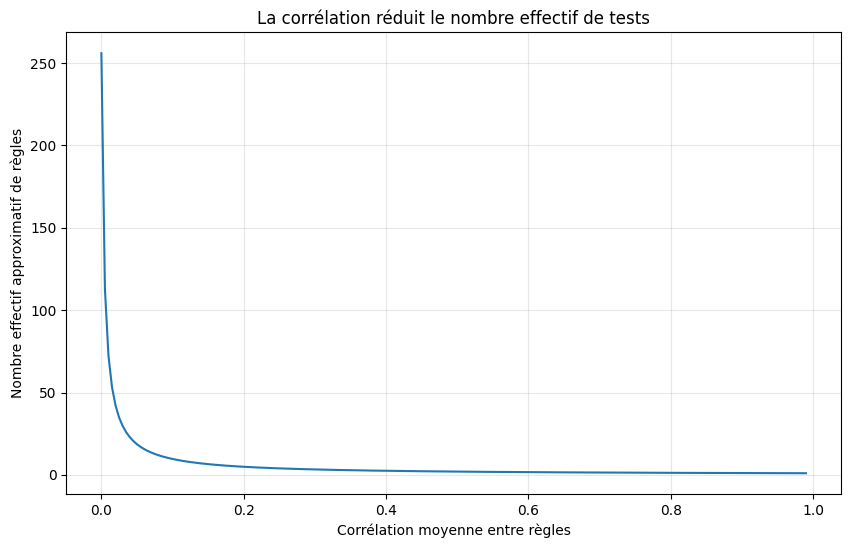

In [8]:
plt.figure(figsize=(10, 6))

rho_grid = np.linspace(0, 0.99, 200)
neff_grid = [effective_number_of_tests(256, rho) for rho in rho_grid]

plt.plot(rho_grid, neff_grid)
plt.xlabel("Corrélation moyenne entre règles")
plt.ylabel("Nombre effectif approximatif de règles")
plt.title("La corrélation réduit le nombre effectif de tests")
plt.grid(True, alpha=0.3)
plt.show()

## 10. Traduction trading concret

Dans un vrai pipeline de backtest, la corrélation apparaît quand tu testes beaucoup de variantes très proches :

| Exemple de règles | Corrélation probable |
|---|---:|
| EMA 20/50, EMA 21/50, EMA 22/50 | Très élevée |
| RSI 14, RSI 15, RSI 16 | Très élevée |
| Breakout Donchian vs breakout range asiatique | Moyenne |
| Momentum trend-following vs mean reversion intraday | Plus faible |
| Stratégie order flow vs stratégie saisonnalité | Plus faible |

Donc tester 500 variantes d’une même idée peut donner l’illusion d’un grand univers.

Mais statistiquement, tu n’as peut-être testé que quelques idées distinctes.

> En EBTA, la quantité brute de règles testées est moins importante que la diversité réelle des hypothèses testées.

## 11. Application pratique dans ton workflow EBTA

Avant d’optimiser massivement une famille de stratégies, tu peux mesurer la corrélation des performances entre règles.

Exemple :

- Chaque colonne représente une stratégie.
- Chaque ligne représente une période : jour, semaine, mois ou trade.
- On calcule la matrice de corrélation.
- On observe si les stratégies sont réellement différentes.

Cela permet de savoir si ton univers est :

- **Large en apparence**, mais redondant.
- Ou **large en réalité**, donc puissant mais statistiquement dangereux.

In [19]:
# Exemple fictif : matrice de rendements de stratégies
# rows = périodes, columns = stratégies

rng_demo = np.random.default_rng(7)

n_periods = 250
n_strategies = 12
rho_demo = 0.75

common = rng_demo.normal(0, 1, size=(n_periods, 1))
idio = rng_demo.normal(0, 1, size=(n_periods, n_strategies))

strategy_returns = np.sqrt(rho_demo) * common + np.sqrt(1 - rho_demo) * idio
strategy_returns = pd.DataFrame(
    strategy_returns,
    columns=[f"strategie_{i+1}" for i in range(n_strategies)]
)

corr_matrix = strategy_returns.corr()

display(corr_matrix.round(2))

,strategie_1,strategie_2,strategie_3,strategie_4,strategie_5,strategie_6,strategie_7,strategie_8,strategie_9,strategie_10,strategie_11,strategie_12
strategie_1,1.00,0.69,0.73,0.75,0.75,0.75,0.70,0.69,0.70,0.72,0.73,0.74
strategie_2,0.69,1.00,0.68,0.70,0.69,0.72,0.70,0.69,0.71,0.71,0.71,0.70
strategie_3,0.73,0.68,1.00,0.73,0.75,0.74,0.73,0.71,0.71,0.73,0.74,0.74
strategie_4,0.75,0.70,0.73,1.00,0.74,0.72,0.73,0.76,0.71,0.75,0.73,0.73
strategie_5,0.75,0.69,0.75,0.74,1.00,0.75,0.75,0.74,0.71,0.76,0.74,0.73
strategie_6,0.75,0.72,0.74,0.72,0.75,1.00,0.72,0.74,0.74,0.74,0.75,0.72
strategie_7,0.70,0.70,0.73,0.73,0.75,0.72,1.00,0.74,0.73,0.74,0.71,0.71
strategie_8,0.69,0.69,0.71,0.76,0.74,0.74,0.74,1.00,0.75,0.74,0.73,0.70
strategie_9,0.70,0.71,0.71,0.71,0.71,0.74,0.73,0.75,1.00,0.76,0.71,0.75
strategie_10,0.72,0.71,0.73,0.75,0.76,0.74,0.74,0.74,0.76,1.00,0.72,0.73


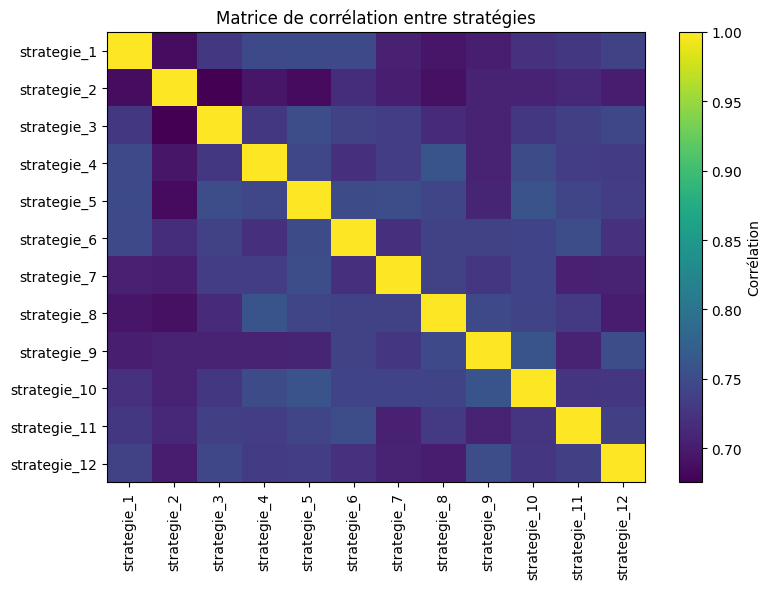

In [20]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Corrélation")
plt.xticks(range(n_strategies), corr_matrix.columns, rotation=90)
plt.yticks(range(n_strategies), corr_matrix.columns)
plt.title("Matrice de corrélation entre stratégies")
plt.tight_layout()
plt.show()

## 12. Checklist de décision

Avant de croire un backtest issu d’une optimisation, pose-toi ces questions :

| Question | Pourquoi c’est important |
|---|---|
| Combien de règles ai-je testées ? | Plus il y en a, plus le biais peut augmenter |
| Ces règles sont-elles vraiment différentes ? | La corrélation réduit le $N_{\text{eff}}$ |
| Le gagnant est-il juste une variante chanceuse ? | Le meilleur backtest peut être un mirage |
| Ai-je mesuré la performance hors-échantillon ? | Le futur teste le mérite réel |
| Ai-je appliqué une correction de data mining ? | WRC, SPA test, bootstrap ou validation robuste |

> Une stratégie trouvée dans un univers très décorrélé doit être validée beaucoup plus durement.

## 13. Eurêka final

> **La corrélation est une protection et une prison.**

Elle protège parce qu’elle réduit le **biais de minage de données**.

Mais elle emprisonne la recherche parce qu’elle réduit le **pouvoir de découverte**.

En trading algorithmique, le vrai objectif n’est donc pas simplement de tester beaucoup de règles.

Le vrai objectif est de construire un univers de règles :

- assez **diversifié** pour découvrir de vrais edges ;
- assez **contrôlé statistiquement** pour ne pas confondre hasard et compétence ;
- assez **validé hors-échantillon** pour survivre au réel.

La formule mentale à retenir est :

$$
\text{Diversité} \uparrow
\Rightarrow
\text{Découverte} \uparrow
\quad \text{mais} \quad
\text{Biais} \uparrow
$$

Et inversement :

$$
\text{Corrélation} \uparrow
\Rightarrow
\text{Biais} \downarrow
\quad \text{mais} \quad
\text{Découverte} \downarrow
$$

## Annexe — Texte source fourni


### **CH 6 : DATA-MINING BIAS AS A FUNCTION OF RULE CORRELATION: IN A UNIVERSE OF VARIABLE MERIT BASED ON 500 ATRs**

Voici l’analyse technique de l’impact de la corrélation sur le biais et sur l'efficacité de la recherche dans un univers réaliste (où le talent des règles varie).

#### **Idées clés :**
*   **Réduction du "N" effectif :** La corrélation entre les règles réduit le nombre effectif de règles testées ; si deux règles sont parfaitement corrélées, elles comptent statistiquement pour une seule.
*   **Lien avec le biais :** Une corrélation élevée réduit mécaniquement le biais de minage de données car elle limite les opportunités pour le hasard de créer une performance divergente.
*   **L'envers de la médaille (Efficacité) :** Une forte corrélation limite la capacité du minage de données à découvrir des règles de haut mérite. Si toutes les règles se ressemblent, la recherche intensive ne produit aucun gain de connaissance.
*   **Le cas limite (0,9) :** Dans un univers corrélé à 0,9, tester 256 règles ne permet de trouver qu'une règle dont le mérite réel est de +1,4 %, soit le même niveau qu'une règle choisie au hasard.

#### **Référence :**
*Data-Mining Bias as a Function of Rule Correlation: In a Universe of Variable Merit Based on 500 ATRs*, Chapitre 6, pages 318 à 319.

#### **Citation Directe :**
« Correlation shrinks the bias because correlation reduces the effective number of rules being examined. In the extreme case, where all rules have perfectly correlated returns, there is really only one rule being tested. » (Page 318).

#### **Vision Macro :**
L'enjeu est de comprendre le compromis entre la **sécurité statistique** et le **pouvoir de découverte**. David Aronson explique que si la corrélation protège le trader contre le biais de minage (moins de risque d'être trompé par un mirage), elle rend également le processus de minage de données stérile. Pour trouver de "l'or véritable" (un avantage prédictif significatif), il est nécessaire de tester des idées variées et indépendantes, tout en acceptant que cela augmente massivement le risque de biais, nécessitant alors des tests de validation (comme le WRC) encore plus rigoureux.

#### **Vision Micro :**
Le mécanisme est illustré par l'expérience sur 500 ATR avec 100 mois d'observations (Figure 6.55) :

1.  **Les quatre niveaux de corrélation :** Aronson teste des niveaux de 0,0 (indépendance totale), 0,3, 0,6 et 0,9.
2.  **Résultat pour la Corrélation 0,0 :** Le minage de données est à son maximum d'efficacité. En testant 256 règles indépendantes, l'ordinateur parvient à débusquer une règle dont le mérite réel (rendement attendu) est proche de **4 %**, bien au-dessus de la moyenne de l'univers (+1,4 %).
3.  **Résultat pour la Corrélation 0,9 :** La courbe reste quasiment plate. Même après 256 tests, le rendement attendu du gagnant n'est que de **1,4 %**. Cela prouve que moins de données sont "explorées" réellement ; l'opportunité de découvrir une règle supérieure est gaspillée par la similitude des candidats.
4.  **L'implication technique :** La corrélation agit comme un filtre qui "écrase" à la fois le biais (le mensonge) et le potentiel de gain (la découverte).

#### **Résumé Simplifié :**
Si tu envoies 100 prospecteurs chercher de l'or mais qu'ils restent tous groupés au même endroit (forte corrélation), ils ne trouveront pas plus d'or qu'un seul homme. S'ils se dispersent (indépendance), ils ont beaucoup plus de chances de trouver une mine, mais ils risquent aussi de prendre beaucoup plus de cailloux brillants pour de l'or par erreur. En trading, optimiser des variantes d'une même idée est "sûr" mais peu productif, tandis que tester des idées très différentes est "productif" mais très risqué statistiquement.

#### **Actions Concrètes :**
*   **Mesurer la corrélation de l'univers :** Avant de lancer une optimisation massive, calculez la corrélation entre vos règles. Si elle est proche de 1.0, sachez que vous perdez votre temps ; vous n'apprenez rien de nouveau.
*   **Diversifier les logiques :** Pour que le minage de données soit rentable, incluez des règles basées sur des concepts différents (ex: Momentum vs Mean Reversion) afin de maximiser le potentiel de découverte.
*   **Ajuster la validation :** Soyez conscient que plus vos règles sont décorrélées, plus vous devez exiger une performance de backtest élevée pour compenser un biais de minage qui sera mécaniquement plus grand.

#### **À retenir absolument :**
*   **Corrélation élevée = Biais faible**, mais découverte faible.
*   **Indépendance = Biais élevé**, mais découverte maximale.
*   Tester des variantes corrélées revient à **ne tester qu'une seule règle**.
*   Le minage de données nécessite de la **diversité** pour porter ses fruits.
*   À 0,9 de corrélation, le minage de données **échoue à battre le hasard**.

J'ai terminé l'analyse de l'impact de la corrélation dans un univers de mérite variable selon le protocole EBTA.